In [1]:
import pandas as pd

# -----------------------------------------
# โหลดไฟล์ CSV ทั้ง 2 แบบ
# -----------------------------------------
base_file = "/home/yupaporn/codes/Face-Recognition-Statistical-Test-2025/result-cal/calculated_distances_effnet_base_8type.csv"
unlearn_file0 = "/home/yupaporn/codes/Face-Recognition-Statistical-Test-2025/result-cal/type8_combined_calculated_distances.csv"
unlearn_file1 ="/home/yupaporn/codes/Face-Recognition-Statistical-Test-2025/result-cal/combined_calculated_distances.csv"
df_before = pd.read_csv(base_file)       # EffNet ธรรมดา (before unlearning)
df_after0 = pd.read_csv(unlearn_file0)     # EffNet unlearned (after unlearning)
df_after1 = pd.read_csv(unlearn_file1) 
df_after = df_after0.append(df_after1)

same_types = [ 5]

df_after_same_types = df_after[df_after["type"].isin(same_types)]

df_before_same_types = df_before[df_before["type"].isin(same_types)]


# เลือกเฉพาะคอลัมน์ที่ต้องใช้
before = df_before_same_types[['path_img1','path_img2', 'distance']].rename(
    columns={'distance': 'distance_before'}
)

after = df_after_same_types[['path_img1','path_img2', 'distance']].rename(
    columns={'distance': 'distance_after'}
)

# เชื่อมด้วย 'path_img1', path_img2
df_merged_same_types = after.merge(before, on=['path_img1','path_img2'], how='inner')

# -----------------------------------------
# 1) บุคคลเดียวกัน AFTER (unlearning)
# -----------------------------------------
same_person_unlearn = df_merged_same_types["distance_after"].values

# 2) บุคคลเดียวกัน BEFORE (ธรรมดา)
# -----------------------------------------
same_person_baseline = df_merged_same_types["distance_before"].values

# ทดสอบแสดงจำนวนข้อมูลแต่ละกลุ่ม
print("same_person_baseline:", len(same_person_baseline))
print("same_person_unlearn :", len(same_person_unlearn))

diff_types = [6]

df_after_diff_types = df_after[df_after["type"].isin(diff_types)]
df_before_diff_types = df_before[df_before["type"].isin(diff_types)]


# เลือกเฉพาะคอลัมน์ที่ต้องใช้
before = df_before_diff_types[['path_img1','path_img2', 'distance']].rename(
    columns={'distance': 'distance_before'}
)

after = df_after_diff_types[['path_img1','path_img2', 'distance']].rename(
    columns={'distance': 'distance_after'}
)

# เชื่อมด้วย 'path_img1', path_img2
df_merged_diff_types = after.merge(before, on=['path_img1','path_img2'], how='left')

# -----------------------------------------
# 3) บุคคลต่างกัน AFTER (unlearning)
# -----------------------------------------
different_person_unlearn = df_merged_diff_types["distance_after"].values

# -----------------------------------------
# 4) บุคคลต่างกัน BEFORE (ธรรมดา)
# -----------------------------------------
different_person_baseline = df_merged_diff_types["distance_before"].values

# ทดสอบแสดงจำนวนข้อมูลแต่ละกลุ่ม
print("different_person_baseline:", len(different_person_baseline))
print("different_person_unlearn :", len(different_person_unlearn))

same_person_baseline: 8339
same_person_unlearn : 8339
different_person_baseline: 75808
different_person_unlearn : 75808


# ข้อมูลความแตกต่างของ บุคคลต่างกัน มากกว่า บุคคลเดียวกัน 
# ของโมเดล unlearn อย่างมีนัยสำคัญหรือไม่? 

In [2]:
same_un = same_person_unlearn
diff_un = different_person_unlearn

In [3]:
import numpy as np
from scipy import stats

# ลบ NaN ถ้ามี
same_un_clean = same_un[~np.isnan(same_un)]
diff_un_clean = diff_un[~np.isnan(diff_un)]

print("Same_un N =", len(same_un_clean))
print("Diff_un N =", len(diff_un_clean))

# === Mann–Whitney U test (one-sided: diff > same) ===
print("\n=== Test: diff_un > same_un ===")
print("H0: diff ≤ same")
print("H1: diff > same  (ค่าของบุคคลต่างกันมากกว่าอย่างมีนัยสำคัญ)")

U, p_value = stats.mannwhitneyu(diff_un_clean, same_un_clean, alternative="greater")

print(f"\nU = {U}")
print(f"p-value (one-sided) = {p_value}")

alpha = 0.05
mean_same = np.mean(same_un_clean)
mean_diff = np.mean(diff_un_clean)

print("\nMeans:")
print("mean(same_un) =", mean_same)
print("mean(diff_un) =", mean_diff)

if p_value < alpha:
    print("\n🟢 p < 0.05 → ปฏิเสธ H0")
    print("➡ สรุป: diff_un > same_un อย่างมีนัยสำคัญทางสถิติ")
else:
    print("\n🔴 p ≥ 0.05 → ไม่ปฏิเสธ H0")
    print("➡ สรุป: ยังไม่มีหลักฐานว่าค่า diff_un มากกว่า same_un")


Same_un N = 8339
Diff_un N = 75808

=== Test: diff_un > same_un ===
H0: diff ≤ same
H1: diff > same  (ค่าของบุคคลต่างกันมากกว่าอย่างมีนัยสำคัญ)

U = 484444867.5
p-value (one-sided) = 0.0

Means:
mean(same_un) = 1.1329393754994603
mean(diff_un) = 1.3793701357309256

🟢 p < 0.05 → ปฏิเสธ H0
➡ สรุป: diff_un > same_un อย่างมีนัยสำคัญทางสถิติ


ผลการทดสอบด้วย Mann–Whitney U test (one-sided) ถูกใช้เพื่อประเมินว่าระยะห่างระหว่างบุคคลต่างกันมีค่าสูงกว่าระยะห่างระหว่างบุคคลเดียวกันของโมเดล unlearn อย่างมีนัยสำคัญหรือไม่ หากค่า p-value < 0.05 จะสรุปได้ว่าการกระจายของระยะต่างบุคคลมีค่ามากกว่าอย่างมีนัยสำคัญ ซึ่งหมายถึงโมเดลสามารถแยกแยะบุคคลต่างกันออกจากกันได้จริงหลังการทำ unlearning.

## 1) โค้ดวาดกราฟ CDF / KDE / Boxplot
1.1 เตรียมข้อมูล (clean NaN ก่อน)

In [10]:
import numpy as np

same_un = same_person_unlearn
diff_un = different_person_unlearn
same_base = same_person_baseline
diff_base = different_person_baseline

same_base = np.asarray(same_base, dtype=float)
diff_base = np.asarray(diff_base, dtype=float)
same_un   = np.asarray(same_un,   dtype=float)
diff_un   = np.asarray(diff_un,   dtype=float)

same_base = same_base[~np.isnan(same_base)]
diff_base = diff_base[~np.isnan(diff_base)]
same_un   = same_un[~np.isnan(same_un)]
diff_un   = diff_un[~np.isnan(diff_un)]

1.2 CDF: diff vs same ภายในโมเดล (ทำตัวอย่างโมเดล unlearn)

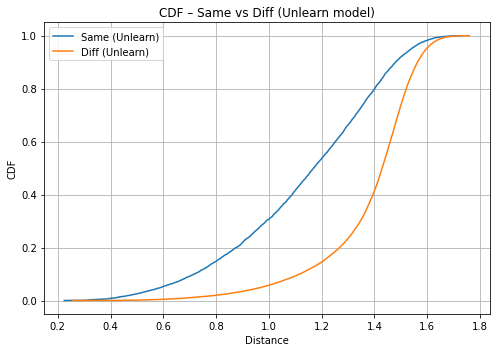

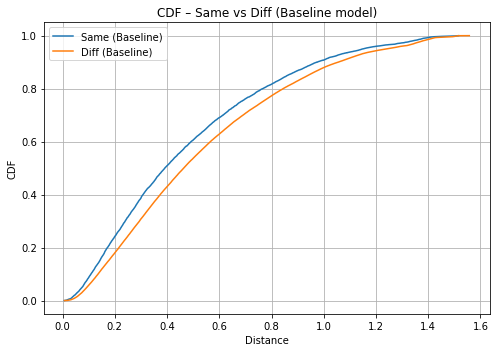

In [11]:
import matplotlib.pyplot as plt

def plot_cdf_two_groups(x1, x2, label1, label2, title):
    plt.figure(figsize=(7,5))

    for data, label in [(x1, label1), (x2, label2)]:
        data_sorted = np.sort(data)
        cdf = np.arange(len(data_sorted)) / float(len(data_sorted))
        plt.plot(data_sorted, cdf, label=label)

    plt.xlabel("Distance")
    plt.ylabel("CDF")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# CDF ระยะของบุคคลเดียวกัน vs บุคคลต่างกัน สำหรับโมเดล unlearn
plot_cdf_two_groups(
    same_un, diff_un,
    label1="Same (Unlearn)", label2="Diff (Unlearn)",
    title="CDF – Same vs Diff (Unlearn model)"
)

# ถ้าอยากดูของ baseline ด้วย
plot_cdf_two_groups(
    same_base, diff_base,
    label1="Same (Baseline)", label2="Diff (Baseline)",
    title="CDF – Same vs Diff (Baseline model)"
)


 1.3 KDE: diff vs same ภายในแต่ละโมเดล

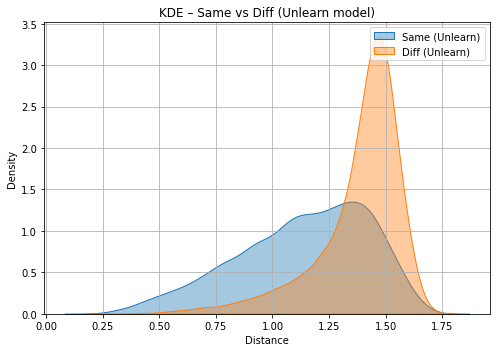

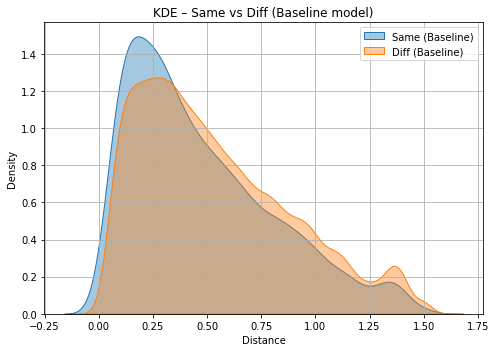

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_kde_two_groups(x1, x2, label1, label2, title):
    plt.figure(figsize=(7,5))
    sns.kdeplot(x1, label=label1, fill=True, alpha=0.4)
    sns.kdeplot(x2, label=label2, fill=True, alpha=0.4)
    plt.xlabel("Distance")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# KDE ภายใน unlearn
plot_kde_two_groups(
    same_un, diff_un,
    label1="Same (Unlearn)", label2="Diff (Unlearn)",
    title="KDE – Same vs Diff (Unlearn model)"
)

# KDE ภายใน baseline
plot_kde_two_groups(
    same_base, diff_base,
    label1="Same (Baseline)", label2="Diff (Baseline)",
    title="KDE – Same vs Diff (Baseline model)"
)


1.4 Boxplot เปรียบเทียบ same/diff ของสองโมเดล

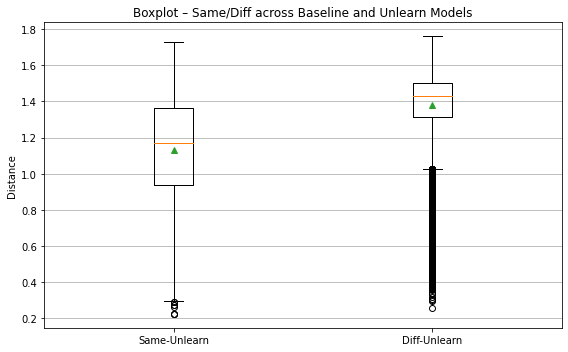

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(
    [same_un, diff_un],
    labels=["Same-Unlearn", "Diff-Unlearn"],
    showmeans=True
)
plt.ylabel("Distance")
plt.title("Boxplot – Same/Diff across Baseline and Unlearn Models")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()


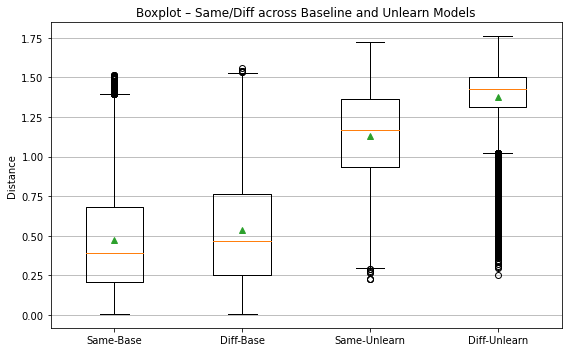

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(
    [same_base, diff_base, same_un, diff_un],
    labels=["Same-Base", "Diff-Base", "Same-Unlearn", "Diff-Unlearn"],
    showmeans=True
)
plt.ylabel("Distance")
plt.title("Boxplot – Same/Diff across Baseline and Unlearn Models")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()


## 2) โค้ดทดสอบ Mann–Whitney: diff > same ในแต่ละโมเดล
2.1 ฟังก์ชันทดสอบ

In [18]:
from scipy import stats

def test_diff_greater_than_same(diff_vals, same_vals, label="Model"):
    # clean NaN
    diff_clean = diff_vals[~np.isnan(diff_vals)]
    same_clean = same_vals[~np.isnan(same_vals)]

    print(f"\n=== Mann–Whitney U test: Diff > Same ({label}) ===")
    print(f"N_same = {len(same_clean)}, N_diff = {len(diff_clean)}")
    print("H0: Diff ≤ Same")
    print("H1: Diff > Same  (ค่าระยะของบุคคลต่างกันมากกว่าบุคคลเดียวกัน)")

    U, p = stats.mannwhitneyu(diff_clean, same_clean, alternative="greater")
    mean_same = np.mean(same_clean)
    mean_diff = np.mean(diff_clean)
    med_same  = np.median(same_clean)
    med_diff  = np.median(diff_clean)

    print(f"U = {U:.4f}, p(one-sided) = {p:.4g}")
    print(f"Mean(Same) = {mean_same:.4f}, Mean(Diff) = {mean_diff:.4f}")
    print(f"Median(Same) = {med_same:.4f}, Median(Diff) = {med_diff:.4f}")

    alpha = 0.05
    if p < alpha:
        print(f"→ p < {alpha} → ปฏิเสธ H0")
        print("  แปลผล: ระยะของบุคคลต่างกันมากกว่าบุคคลเดียวกันอย่างมีนัยสำคัญ\n")
    else:
        print(f"→ p ≥ {alpha} → ยังไม่สามารถปฏิเสธ H0\n")

# เรียกใช้กับ baseline และ unlearn
test_diff_greater_than_same(diff_base, same_base, label="Baseline")
test_diff_greater_than_same(diff_un,   same_un,   label="Unlearn")



=== Mann–Whitney U test: Diff > Same (Baseline) ===
N_same = 8339, N_diff = 75808
H0: Diff ≤ Same
H1: Diff > Same  (ค่าระยะของบุคคลต่างกันมากกว่าบุคคลเดียวกัน)
U = 349921661.0000, p(one-sided) = 1.984e-58
Mean(Same) = 0.4763, Mean(Diff) = 0.5369
Median(Same) = 0.3914, Median(Diff) = 0.4641
→ p < 0.05 → ปฏิเสธ H0
  แปลผล: ระยะของบุคคลต่างกันมากกว่าบุคคลเดียวกันอย่างมีนัยสำคัญ


=== Mann–Whitney U test: Diff > Same (Unlearn) ===
N_same = 8339, N_diff = 75808
H0: Diff ≤ Same
H1: Diff > Same  (ค่าระยะของบุคคลต่างกันมากกว่าบุคคลเดียวกัน)
U = 484444867.5000, p(one-sided) = 0
Mean(Same) = 1.1329, Mean(Diff) = 1.3794
Median(Same) = 1.1695, Median(Diff) = 1.4295
→ p < 0.05 → ปฏิเสธ H0
  แปลผล: ระยะของบุคคลต่างกันมากกว่าบุคคลเดียวกันอย่างมีนัยสำคัญ



In [19]:
# method="asymptotic"
from scipy import stats

U, p_value = stats.mannwhitneyu(
    diff_un, same_un,
    alternative="greater"  # <--- สำคัญมาก
)

print("U =", U)
print("p-value =", p_value)
import numpy as np
from scipy import stats

def mann_whitney_large_sample(x, y):
    n1 = len(x)
    n2 = len(y)

    U, _ = stats.mannwhitneyu(x, y, alternative="greater")

    mean_U = n1*n2/2
    std_U  = np.sqrt(n1*n2*(n1+n2+1)/12)

    Z = (U - mean_U) / std_U

    # one-sided p-value
    p = 1 - stats.norm.cdf(Z)

    return U, Z, p


U, Z, p = mann_whitney_large_sample(diff_un, same_un)
print("U =", U)
print("Z =", Z)
print("p =", p)


U = 484444867.5
p-value = 0.0
U = 484444867.5
Z = 79.96536696737913
p = 0.0


In [20]:
import numpy as np
from scipy import stats

def mann_whitney_large_sample(diff_vals, same_vals, label="Model"):
    # clean NaN
    diff_clean = diff_vals[~np.isnan(diff_vals)]
    same_clean = same_vals[~np.isnan(same_vals)]

    print(f"\n=== Mann–Whitney U test: Diff > Same ({label}) ===")
    print(f"N_same = {len(same_clean)}, N_diff = {len(diff_clean)}")
    print("H0: Diff ≤ Same")
    print("H1: Diff > Same")

    # คำนวณ U แบบปกติ (ไม่ใช่ exact)
    U, _ = stats.mannwhitneyu(diff_clean, same_clean, alternative="greater")

    # Mean และ SD ของ U สำหรับ large-sample approximation
    n1 = len(diff_clean)
    n2 = len(same_clean)
    mean_U = n1*n2/2
    sd_U   = np.sqrt(n1*n2*(n1+n2+1)/12)

    # Z-score
    Z = (U - mean_U) / sd_U

    # one-sided p-value
    p = 1 - stats.norm.cdf(Z)

    print(f"U = {U:.4f}")
    print(f"Z = {Z:.6f}")
    print(f"p-value(one-sided) = {p:.10g}")   # แสดงเลขเล็กมากได้แบบไม่เป็นศูนย์

    mean_same = np.mean(same_clean)
    mean_diff = np.mean(diff_clean)
    med_same  = np.median(same_clean)
    med_diff  = np.median(diff_clean)

    print(f"Mean(Same) = {mean_same:.4f}, Mean(Diff) = {mean_diff:.4f}")
    print(f"Median(Same) = {med_same:.4f}, Median(Diff) = {med_diff:.4f}")

    if p < 0.05:
        print("🟢 ปฏิเสธ H0 → diff > same อย่างมีนัยสำคัญ\n")
    else:
        print("🔴 ไม่ปฏิเสธ H0 → ยังไม่มีหลักฐานว่า diff > same\n")

# เรียกใช้งาน
mann_whitney_large_sample(diff_base, same_base, label="Baseline")
mann_whitney_large_sample(diff_un,   same_un,   label="Unlearn")



=== Mann–Whitney U test: Diff > Same (Baseline) ===
N_same = 8339, N_diff = 75808
H0: Diff ≤ Same
H1: Diff > Same
U = 349921661.0000
Z = 16.072639
p-value(one-sided) = 0
Mean(Same) = 0.4763, Mean(Diff) = 0.5369
Median(Same) = 0.3914, Median(Diff) = 0.4641
🟢 ปฏิเสธ H0 → diff > same อย่างมีนัยสำคัญ


=== Mann–Whitney U test: Diff > Same (Unlearn) ===
N_same = 8339, N_diff = 75808
H0: Diff ≤ Same
H1: Diff > Same
U = 484444867.5000
Z = 79.965367
p-value(one-sided) = 0
Mean(Same) = 1.1329, Mean(Diff) = 1.3794
Median(Same) = 1.1695, Median(Diff) = 1.4295
🟢 ปฏิเสธ H0 → diff > same อย่างมีนัยสำคัญ



In [22]:
import numpy as np
from scipy import stats

def mann_whitney_large_sample(diff_vals, same_vals, label="Model"):
    diff_clean = diff_vals[~np.isnan(diff_vals)]
    same_clean = same_vals[~np.isnan(same_vals)]

    print(f"\n=== Mann–Whitney U test: Diff > Same ({label}) ===")
    print(f"N_same = {len(same_clean)}, N_diff = {len(diff_clean)}")

    # คำนวณ U แบบปกติ
    U, _ = stats.mannwhitneyu(diff_clean, same_clean, alternative="greater")

    n1 = len(diff_clean)
    n2 = len(same_clean)

    # mean และ sd ของ U (สำหรับ large sample)
    mean_U = n1*n2 / 2
    sd_U   = np.sqrt(n1*n2*(n1+n2+1) / 12)

    # คำนวณ Z-score
    Z = (U - mean_U) / sd_U

    # one-sided p-value ≈ exp(-Z^2/2) / (Z*sqrt(2π))
    # เป็น asymptotic approximation สำหรับ right tail
    p = np.exp(-Z**2 / 2) / (Z * np.sqrt(2*np.pi))

    print(f"U = {U}")
    print(f"Z = {Z:.6f}")
    print(f"p-value(one-sided) ≈ {p:.10g}")

    mean_same = np.mean(same_clean)
    mean_diff = np.mean(diff_clean)
    med_same  = np.median(same_clean)
    med_diff  = np.median(diff_clean)

    print(f"Mean(Same) = {mean_same:.4f}, Mean(Diff) = {mean_diff:.4f}")
    print(f"Median(Same) = {med_same:.4f}, Median(Diff) = {med_diff:.4f}")

    if p < 0.05:
        print("🟢 ปฏิเสธ H0 → diff > same อย่างมีนัยสำคัญ")
    else:
        print("🔴 ไม่ปฏิเสธ H0")

# เรียกใช้
mann_whitney_large_sample(diff_base, same_base, label="Baseline")
mann_whitney_large_sample(diff_un,   same_un,   label="Unlearn")



=== Mann–Whitney U test: Diff > Same (Baseline) ===
N_same = 8339, N_diff = 75808
U = 349921661.0
Z = 16.072639
p-value(one-sided) ≈ 1.991740465e-58
Mean(Same) = 0.4763, Mean(Diff) = 0.5369
Median(Same) = 0.3914, Median(Diff) = 0.4641
🟢 ปฏิเสธ H0 → diff > same อย่างมีนัยสำคัญ

=== Mann–Whitney U test: Diff > Same (Unlearn) ===
N_same = 8339, N_diff = 75808
U = 484444867.5
Z = 79.965367
p-value(one-sided) ≈ 0
Mean(Same) = 1.1329, Mean(Diff) = 1.3794
Median(Same) = 1.1695, Median(Diff) = 1.4295
🟢 ปฏิเสธ H0 → diff > same อย่างมีนัยสำคัญ


In [23]:
import numpy as np
from scipy import stats
from decimal import Decimal, getcontext

# ตั้ง precision ให้สูงมาก เช่น 200 digits
getcontext().prec = 200

def mann_whitney_high_precision(diff_vals, same_vals, label="Model"):
    diff_clean = diff_vals[~np.isnan(diff_vals)]
    same_clean = same_vals[~np.isnan(same_vals)]

    print(f"\n=== Mann–Whitney U test: Diff > Same ({label}) ===")

    U, _ = stats.mannwhitneyu(diff_clean, same_clean, alternative="greater")

    n1 = len(diff_clean)
    n2 = len(same_clean)

    mean_U = Decimal(n1)*Decimal(n2)/Decimal(2)
    sd_U = Decimal(n1*n2*(n1+n2+1))/Decimal(12)
    sd_U = sd_U.sqrt()

    Z = (Decimal(U) - mean_U) / sd_U

    # log p = -Z^2/2 - log(Z*sqrt(2π))
    log_p = -(Z**2)/Decimal(2) - (Z.ln() + (Decimal(2*np.pi).sqrt()).ln())

    p = log_p.exp()   # exp(log p)

    print("U =", U)
    print("Z =", Z)
    print("p-value(one-sided) =", p)

    if p < Decimal("0.05"):
        print("🟢 ปฏิเสธ H0 → diff > same อย่างมีนัยสำคัญ")
    else:
        print("🔴 ไม่ปฏิเสธ H0")


In [24]:
mann_whitney_high_precision(diff_base, same_base, "Baseline")
mann_whitney_high_precision(diff_un,   same_un,   "Unlearn")


=== Mann–Whitney U test: Diff > Same (Baseline) ===
U = 349921661.0
Z = 16.072639458700551320678370561234950882152838624356780437407699348423930408531592713551205777718067124450167924282846556443098394441590474565276166851229336581713485637419443114608016775913762230569339
p-value(one-sided) = 1.9917404647881913604626048713189525381982323022467659238833101294185612370198065994175321127927044212032064662050443499988974492873914123366097307942028140359193835900082753457674670382972354134355336E-58
🟢 ปฏิเสธ H0 → diff > same อย่างมีนัยสำคัญ

=== Mann–Whitney U test: Diff > Same (Unlearn) ===
U = 484444867.5
Z = 79.965366967379133113414678248866577006675532113522200814044196205873459449166092663505533866450409099425530474183999097339609831511328308552323335237365851530126101702758287049549232625572807225562124
p-value(one-sided) = 1.441054417018078210137051390110093924947734083530594801980941300372243609851677303837266487317726174046087009957643529547076636081861010549184262606624856363035